In [1]:
import numpy as np
import pandas as pd
import matplotlib as plot
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [2]:
file_path = "./feature_tsv/feature_table_0.8_pruning.tsv"
df = pd.read_csv(file_path, delimiter = '\t')

In [3]:
df

,sex_n_male,radiation_status_n,age_mtx_initiation_year,pc1,pc2,pc3,pc4,phenotype,cadd_max_agt,cadd_max_csnk1a1,...,rs7936582,rs853463,rs853464,rs853469,rs874628,rs9462081,rs9658119,rs999813,rs2395617,rs3802746
0,1,0,7.780822,-0.008225,-0.018864,0.006900,-0.005783,0,4.126,9.385,...,1,1,1,1,1,1,1,1,1,1
1,0,1,14.980822,-0.008115,-0.019028,0.007100,-0.008543,0,2.187,7.734,...,1,1,1,1,1,1,1,1,1,1
2,0,0,10.668493,-0.007969,-0.017907,0.008996,-0.006286,0,2.337,0.000,...,1,1,1,1,1,1,1,1,1,1
3,1,0,16.668493,-0.008477,-0.018374,0.007729,-0.006396,0,2.337,0.000,...,1,1,1,1,1,1,1,1,1,1
4,0,0,3.978142,-0.009009,-0.017572,0.007017,-0.005674,0,2.229,0.000,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,0,1,3.803279,-0.007823,-0.017980,0.008654,-0.003262,0,2.229,9.385,...,1,1,1,1,1,1,1,1,1,1
273,0,0,10.865753,-0.009132,-0.012447,-0.005812,-0.005802,0,4.126,0.000,...,1,1,1,1,1,1,1,1,1,1
274,0,1,0.931507,-0.008285,-0.017897,0.007320,-0.007484,1,4.126,0.000,...,1,1,1,1,1,1,1,1,1,1
275,0,0,0.868493,-0.008345,-0.018308,0.006325,-0.006692,1,2.187,4.452,...,1,1,1,1,1,1,1,1,1,1


* Examine missing data below and found that 3 missing values in the radiation_status_n, 15 missig in cadd_phred 

In [4]:
df.isna().sum().sum()

0

#### Target distribution
Examine phenotype distribution


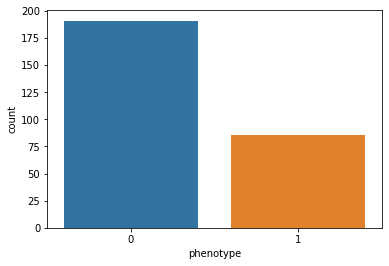

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='phenotype', data=df)

plt.show()

#### Correlation between continous features

![corr](./plot/correlation_continous.png)

### Gradient Boosting Decision Tree

#### Hyperparameter Tuning
Grid search is employed to identify the optimal hyperparameters for the gradient boosting model, ensuring the model is well-suited for the task. To achieve this,  a cross entropy loss is then employed  as the evaluation metric and apply 5-fold cross validation for assessing the model with the large study data. 
1. Due to the unbalanced target distribution. The default scoring (mean accuracy) ill be biased towards the majority class 
2. F1 score is a harmonic mean of precision and recall, providing a balanced measure of both parameters. 
The best hyperparameters are displayed below:

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('phenotype', axis=1), df['phenotype'], test_size=0.2, random_state=42)

In [7]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

clf = GradientBoostingClassifier(random_state=0)
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3], 
}
grid_search = GridSearchCV(clf, param_grid, cv=5, n_jobs=-1, verbose=1, return_train_score=True, scoring="roc_auc")
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
{'learning_rate': 0.2, 'max_depth': 9, 'n_estimators': 100}


In [8]:
#export dataframe for Rstudio to make better plot
import os
plot_dir = "./plot"

if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)
    
grid_search.cv_results_ = pd.DataFrame(grid_search.cv_results_)
grid_search.cv_results_.to_csv(os.path.join(plot_dir, 'grid_search_result.csv'),index=False)

In [9]:
grid_search.cv_results_.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_learning_rate', 'param_max_depth', 'param_n_estimators',
       'params', 'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score', 'split0_train_score',
       'split1_train_score', 'split2_train_score', 'split3_train_score',
       'split4_train_score', 'mean_train_score', 'std_train_score'],
      dtype='object')

![grid_search lineplot](./plot/Rplot01.png)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
{learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 100} appear to yield the best model performance per auc-roc socre. 

#### Confusion Matrix

We then use the best hyperparameters to train the model and make predictions on the investigational cohort high dose data. The confusion matrix of the predictions is shown below: 

In [10]:
%store grid_search 

Stored 'grid_search' (GridSearchCV)


In [11]:
%store -r grid_search

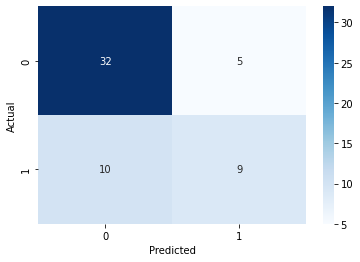

In [12]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = grid_search.best_estimator_.predict(X_test)
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

32 true negative, 5 false positive, 10 false negative and 9 true negative.

###### Cross entropy loss
The cross entropy loss calculated on the test set is shown below:

In [13]:
import numpy as np
from sklearn.metrics import log_loss

y_pred = grid_search.best_estimator_.predict_proba(X_test)
# cross entropy loss
base_line = log_loss(y_test, y_pred)
 

In [14]:
base_line

4.09220084655046

__Prediction Distribution__

The prediction distribution and actual distribution are shown below:

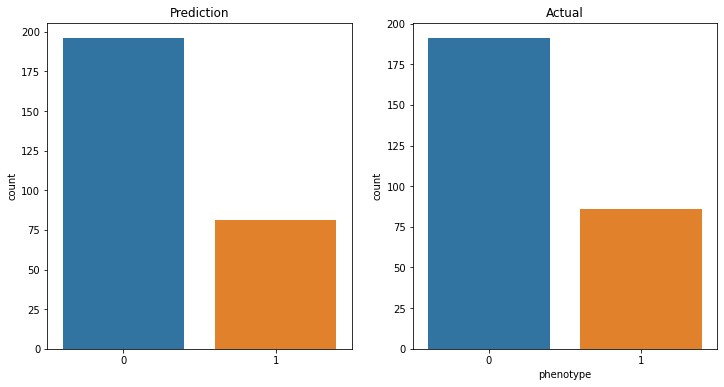

In [15]:
# prediction distribution and actual distribution
# make them subplot
import matplotlib.pyplot as plt

y_pred = grid_search.best_estimator_.predict(df.drop('phenotype', axis=1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
sns.countplot(x=y_pred, ax=ax1)
ax1.set_title('Prediction')
sns.countplot(x=df['phenotype'], ax=ax2)
ax2.set_title('Actual')
plt.show()

__Feature Importance__

The feature importance is shown below:

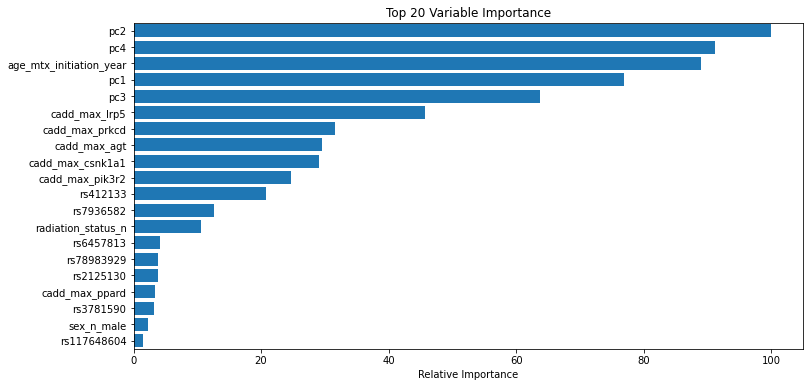

In [16]:
# feature importance
import matplotlib.pyplot as plt

feature_importance = grid_search.best_estimator_.feature_importances_
feature_importance = 100.0 * (feature_importance / feature_importance.max())
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + .5
plt.figure(figsize=(12, 6))
plt.barh(pos, feature_importance[sorted_idx], align='center')
plt.yticks(pos, df.drop('phenotype', axis=1).columns[sorted_idx])
plt.xlabel('Relative Importance')
plt.ylim(len(feature_importance)-20, len(feature_importance))
plt.title('Top 20 Variable Importance')
plt.show()

_Under Construction: Waiting for Test Data(replication cohort) and replication cohort contains some of the investigation cohort?_

__Ablation Study__

The ablation study in machine learning is a method to evaluate the importance of individual components or features in a model by systematically removing them and measuring the impact on model performance. This helps us understand which parts of the model contribute most to its success and identify areas for potential improvement.

We then undertake an ablation study to see the effect of each feature on the model performance. The cross entropy loss is shown below:

In [17]:
# # Ablation Study

# from sklearn.model_selection import train_test_split

# X_train, X_test = map(lambda x: x.drop('phenotype', axis=1), (train_data, test_data))
# y_train, y_test = map(lambda x: x['phenotype'], (train_data, test_data))

# from sklearn.metrics import log_loss

# def ablation_study(X_train, X_test, y_train, y_test, feature):
#     X_train = X_train.drop(feature, axis=1)
#     X_test = X_test.drop(feature, axis=1)
#     clf = GradientBoostingClassifier(**grid_search.best_params_)
#     clf.fit(X_train, y_train)
#     y_pred = clf.predict_proba(X_test)
#     y_true = pd.get_dummies(y_test).values
#     y_true = np.insert(y_true, 1, 0, axis=1)
#     return base_line - log_loss(y_true, y_pred)

# ablation_scores = dict()
# for feature in X_train.columns:
#     ablation_scores[feature] = ablation_study(X_train, X_test, y_train, y_test, feature)